In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfin

In [ ]:
#a
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)
data = ticker.history(period='5y')

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-01-06 00:00:00-05:00,157.324005,159.875504,156.557999,156.919006,87896000,0.0,0.0
2021-01-07 00:00:00-05:00,157.850006,160.427002,157.750000,158.108002,70290000,0.0,0.0
2021-01-08 00:00:00-05:00,159.000000,159.531998,157.110001,159.134995,70754000,0.0,0.0
2021-01-11 00:00:00-05:00,157.400497,157.819000,155.500000,155.710495,73668000,0.0,0.0
2021-01-12 00:00:00-05:00,156.000000,157.106995,154.300003,156.041504,70292000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-29 00:00:00-05:00,231.940002,232.600006,230.770004,232.070007,19797900,0.0,0.0
2025-12-30 00:00:00-05:00,231.210007,232.770004,230.199997,232.529999,21910500,0.0,0.0
2025-12-31 00:00:00-05:00,232.910004,232.990005,230.119995,230.820007,24383700,0.0,0.0


<Axes: xlabel='Date', ylabel='Amazon'>

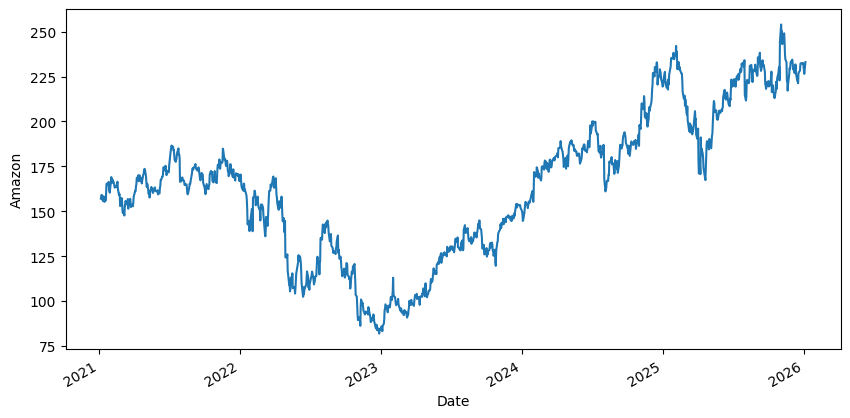

In [ ]:
#a
plt.ylabel("Amazon")
data['Close'].plot(figsize=(10,5))

In [ ]:
#b
#simple moving averages (SMA)
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['SMA_50'] = data['Close'].shift(1).rolling(window=50).mean()

#exponential moving averages (EMA)
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

#relative strength index (RSI)
delta = data['Close'].diff(1)
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
data['RSI'] = 100 - (100 / (1 + rs))

data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-01-06 00:00:00-05:00,157.324005,159.875504,156.557999,156.919006,87896000,0.0,0.0,NaN,NaN,156.919006,NaN
2021-01-07 00:00:00-05:00,157.850006,160.427002,157.750000,158.108002,70290000,0.0,0.0,NaN,NaN,157.032244,NaN
2021-01-08 00:00:00-05:00,159.000000,159.531998,157.110001,159.134995,70754000,0.0,0.0,NaN,NaN,157.232506,NaN
2021-01-11 00:00:00-05:00,157.400497,157.819000,155.500000,155.710495,73668000,0.0,0.0,NaN,NaN,157.087553,NaN
2021-01-12 00:00:00-05:00,156.000000,157.106995,154.300003,156.041504,70292000,0.0,0.0,NaN,NaN,156.987929,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-29 00:00:00-05:00,231.940002,232.600006,230.770004,232.070007,19797900,0.0,0.0,229.077500,230.408200,229.362729,59.543125
2025-12-30 00:00:00-05:00,231.210007,232.770004,230.199997,232.529999,21910500,0.0,0.0,229.020000,230.760200,229.664374,58.675201
2025-12-31 00:00:00-05:00,232.910004,232.990005,230.119995,230.820007,24383700,0.0,0.0,228.952500,231.150000,229.774434,48.034414


In [ ]:
data = data.dropna()

In [ ]:
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20,RSI
Date,,,,,,,,,,,
2021-03-19 00:00:00-04:00,151.461502,153.864502,150.831497,153.748001,92508000,0.0,0.0,154.428101,159.245760,155.034332,44.547255
2021-03-22 00:00:00-04:00,153.392502,156.328995,153.002502,155.543503,58044000,0.0,0.0,153.990752,159.182340,155.082824,51.282577
2021-03-23 00:00:00-04:00,156.350006,159.100006,156.042496,156.875000,76346000,0.0,0.0,153.816077,159.131050,155.253508,61.539807
2021-03-24 00:00:00-04:00,157.552002,158.015503,154.257507,154.353500,59180000,0.0,0.0,153.673576,159.085850,155.167793,59.169335
2021-03-25 00:00:00-04:00,153.649506,155.488998,151.856995,152.313004,71270000,0.0,0.0,153.492426,159.058710,154.895908,53.723473
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-29 00:00:00-05:00,231.940002,232.600006,230.770004,232.070007,19797900,0.0,0.0,229.077500,230.408200,229.362729,59.543125
2025-12-30 00:00:00-05:00,231.210007,232.770004,230.199997,232.529999,21910500,0.0,0.0,229.020000,230.760200,229.664374,58.675201
2025-12-31 00:00:00-05:00,232.910004,232.990005,230.119995,230.820007,24383700,0.0,0.0,228.952500,231.150000,229.774434,48.034414


In [ ]:
#c
X = data[['SMA_20','SMA_50']]
X.head()

,SMA_20,SMA_50
Date,,
2021-03-19 00:00:00-04:00,154.428101,159.24576
2021-03-22 00:00:00-04:00,153.990752,159.18234
2021-03-23 00:00:00-04:00,153.816077,159.13105
2021-03-24 00:00:00-04:00,153.673576,159.08585
2021-03-25 00:00:00-04:00,153.492426,159.05871


In [ ]:
y = data['Close']
y.head()

,Close
Date,
2021-03-19 00:00:00-04:00,153.748001
2021-03-22 00:00:00-04:00,155.543503
2021-03-23 00:00:00-04:00,156.875000
2021-03-24 00:00:00-04:00,154.353500
2021-03-25 00:00:00-04:00,152.313004


In [ ]:
training = 0.7
t = int(training*len(data))

X_train = X[:t]
y_train = y[:t]

X_test = X[t:]
y_test = y[t:]

In [ ]:
#d
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train,y_train)

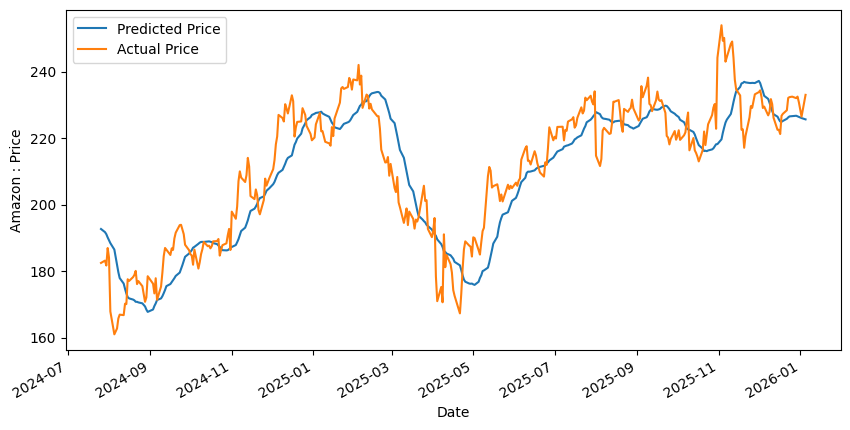

In [ ]:
#e
predicted_price = model.predict(X_test)
predicted_price = pd.DataFrame(predicted_price,index=y_test.index,columns = ['Close'])
predicted_price.plot(figsize=(10,5))
y_test.plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Amazon : Price")
plt.show()

In [ ]:
R_squared_score =model.score(X[t:],y[t:])*100
accuracy = ("{0:.2f}".format(R_squared_score))
print ("The model has a " + accuracy + "% accuracy.")

The model has a 78.12% accuracy.


In [ ]:
#f
print(f'alpha = {model.intercept_}')
print(f'betas = {model.coef_}')

alpha = 3.9691938342359094
betas = [ 1.26983405 -0.2955088 ]


In [ ]:
#g
X_rf = data[['SMA_20', 'EMA_20', 'SMA_50', 'RSI']]
y_rf = data['Close']

X_train_rf = X_rf[:t]
y_train_rf = y_rf[:t]

X_test_rf = X_rf[t:]
y_test_rf = y_rf[t:]


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)


RandomForestRegressor(n_estimators=200, random_state=42)

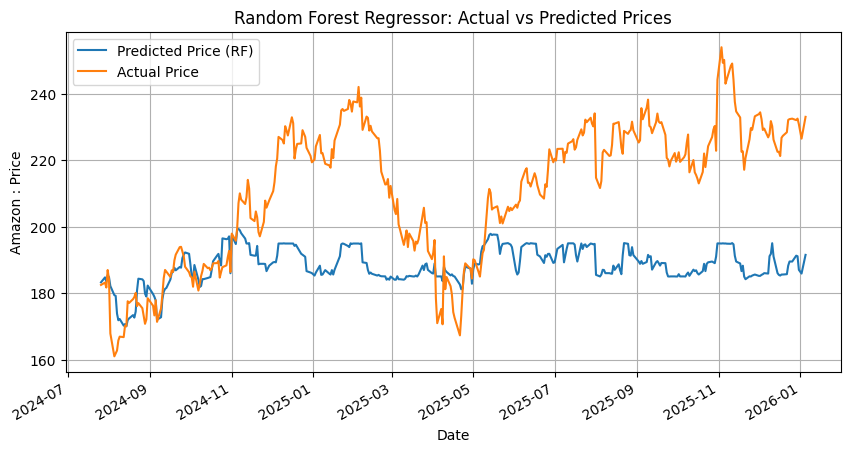

In [ ]:
rf_predicted_price = rf_model.predict(X_test_rf)

rf_predicted_price = pd.DataFrame(
    rf_predicted_price,
    index=y_test_rf.index,
    columns=['Close']
)

rf_predicted_price.plot(figsize=(10,5))
y_test_rf.plot()
plt.legend(['Predicted Price (RF)', 'Actual Price'])
plt.ylabel("Amazon : Price")
plt.title("Random Forest Regressor: Actual vs Predicted Prices")
plt.grid(True)
plt.show()


In [ ]:
rf_accuracy = rf_model.score(X_test_rf, y_test_rf) * 100
print("Random Forest Model Accuracy: {:.2f}%".format(rf_accuracy))

Random Forest Model Accuracy: -92.20%
